In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpmath import quad
from scipy.stats import norm

<div style="background:#fafafa; padding:20px; border-radius:10px; 
            border:1px solid #ddd; font-size:110%;">

<b style="font-size:120%;">Riemann Sums and Numerical Integration</b>

<p>
The modern theory of integration begins with the Riemann integral.  
In this framework, the integral of a function \(f\) over an interval \([a,b]\) is defined 
as the limit of finite sums that approximate the area under the curve.  
A partition
</p>

$$
a = x_0 < x_1 < \cdots < x_n = b
$$

<p>
gives rise to the Riemann sum
</p>

$$
\sum_{k=1}^n f(\xi_k)\,(x_k - x_{k-1}),
$$

<p>
where each sample point \(\xi_k\) lies in the subinterval \([x_{k-1}, x_k]\).  
If these sums converge to the same value for all choices of sample points as the mesh 
\(\max_k (x_k - x_{k-1})\) tends to zero, the function is Riemann integrable.
</p>

<p>
This definition captures the geometric intuition of area and provides a rigorous 
foundation for integration.  
</p>
</div>

<div style="background:#fafafa; padding:20px; border-radius:10px; 
            border:1px solid #ddd; font-size:110%;">

<b style="font-size:120%;">Trapezoidal Rule</b>

<p>
The trapezoidal rule is one of the simplest numerical integration methods.  
It approximates the area under a curve by replacing the function with a straight line 
between two points.  
For a function \(f\) on an interval \([a,b]\), the basic trapezoid approximation is
</p>

$$
\int_a^b f(x)\,dx 
\;\approx\; 
\frac{b-a}{2}\,\bigl(f(a) + f(b)\bigr).
$$

<p>
Geometrically, this corresponds to the area of a trapezoid whose parallel sides have 
lengths \(f(a)\) and \(f(b)\).
</p>

<p><b>Composite trapezoidal rule</b></p>

<p>
To improve accuracy, the interval \([a,b]\) is divided into \(n\) subintervals of equal width
</p>

$$
h = \frac{b-a}{n},
\qquad
x_k = a + k h.
$$

<p>
Applying the trapezoid rule on each subinterval and summing yields
</p>

$$
\int_a^b f(x)\,dx 
\;\approx\;
\frac{h}{2}\Bigl(f(x_0) + 2\sum_{k=1}^{n-1} f(x_k) + f(x_n)\Bigr).
$$

<p>
This composite version converges with order \(O(h^2)\) for sufficiently smooth functions.  
It performs particularly well when the integrand is periodic or when the second derivative 
is small.
</p>

<p><b>Error behavior</b></p>

<p>
If \(f\) is twice continuously differentiable, the error satisfies
</p>

$$
\biggl|\int_a^b f(x)\,dx - T_n\biggr|
\;\le\;
\frac{(b-a)}{12}\,h^2\,\max_{x\in[a,b]} |f''(x)|.
$$

<p>
Thus, halving the step size reduces the error by roughly a factor of four.  
This quadratic convergence makes the trapezoidal rule a natural baseline for comparing 
higher‑order methods such as Simpson’s rule and Gaussian quadrature.
</p>

</div>

In [4]:
class Trapezoid:
    """
    n_evals : Number of function evaluations performed during the last call to integrate().
    """

    def __init__(self):
        self.n_evals = 0

    def integrate(self, f, a, b, n):
        h = (b - a) / n
        self.n_evals = 0

        s = 0.5 * (f(a) + f(b))
        self.n_evals += 2

        for k in range(1, n):
            s += f(a + k * h)
            self.n_evals += 1

        return h * s
    
    def error(self, f, a, b, n, exact):
        approx = self.integrate(f, a, b, n)
        err = abs(approx - exact)
        return approx, err, self.n_evals

In [5]:
f = lambda x: np.exp(-x**2)
exact = 0.7468241328124271  

T = Trapezoid()

for n in [10, 20, 50, 100, 200, 500]:
    approx, err, evals = T.error(f, 0, 1, n, exact)
    print(f"n = {n:4d} | approx = {approx:.10f} | error = {err:.2e} | evals = {evals}")

n =   10 | approx = 0.7462107961 | error = 6.13e-04 | evals = 11
n =   20 | approx = 0.7466708369 | error = 1.53e-04 | evals = 21
n =   50 | approx = 0.7467996072 | error = 2.45e-05 | evals = 51
n =  100 | approx = 0.7468180015 | error = 6.13e-06 | evals = 101
n =  200 | approx = 0.7468226000 | error = 1.53e-06 | evals = 201
n =  500 | approx = 0.7468238876 | error = 2.45e-07 | evals = 501


<div style="background:#fafafa; padding:20px; border-radius:10px; 
            border:1px solid #ddd; font-size:110%;">

<b style="font-size:120%;">Simpson’s Rule</b>

<p>
Simpson’s rule improves on the trapezoidal rule by replacing straight–line 
approximations with <i>quadratic</i> ones.  
On each subinterval, the integrand is approximated by a parabola passing through 
three equally spaced points.  
This yields a fourth–order accurate method that is significantly more efficient 
for smooth functions.
</p>

<p><b>Single–interval Simpson rule</b></p>

<p>
For a function \(f\) on \([a,b]\), let \(m = \tfrac{a+b}{2}\).  
Simpson’s rule on this interval is
</p>

$$
\int_a^b f(x)\,dx 
\;\approx\;
\frac{b-a}{6}\,\bigl(f(a) + 4f(m) + f(b)\bigr).
$$

<p>
The midpoint receives four times the weight of the endpoints because the quadratic 
interpolant bends to match the curvature of the function.
</p>

<p><b>Composite Simpson rule</b></p>

<p>
To integrate over \([a,b]\), the interval is divided into an <i>even</i> number of 
subintervals \(n\), each of width
</p>

$$
h = \frac{b-a}{n}.
$$

<p>
Applying Simpson’s rule on each pair of subintervals gives the composite formula
</p>

$$
\int_a^b f(x)\,dx
\;\approx\;
\frac{h}{3}\Bigl(
f(x_0)
+ 4\sum_{\substack{k=1 \\ k\ \text{odd}}}^{n-1} f(x_k)
+ 2\sum_{\substack{k=2 \\ k\ \text{even}}}^{n-2} f(x_k)
+ f(x_n)
\Bigr),
$$

<p>
where \(x_k = a + kh\).  
The alternating weights \(4,2,4,2,\dots\) reflect the structure of the quadratic 
interpolants.
</p>

<p><b>Error behavior</b></p>

<p>
If \(f\) is four times continuously differentiable, the error satisfies
</p>

$$
\biggl|\int_a^b f(x)\,dx - S_h\biggr|
\;\le\;
\frac{(b-a)}{180}\,h^4\,
\max_{x\in[a,b]} |f^{(4)}(x)|.
$$

<p>
Thus, halving the step size reduces the error by roughly a factor of sixteen.  
This fourth–order convergence makes Simpson’s rule dramatically more accurate than 
the trapezoidal rule for smooth integrands, and it serves as a natural stepping stone 
toward higher–order Newton–Cotes formulas and Gaussian quadrature.
</p>

</div>

In [6]:
class Simpson:
    def __init__(self):
        self.n_evals = 0

    def integrate(self, f, a, b, n):
        if n % 2 != 0:
            raise ValueError("Simpson's rule requires the number of subintervals n to be even.")

        h = (b - a) / n
        self.n_evals = 0

        s = f(a) + f(b)
        self.n_evals += 2

        for k in range(1, n):
            xk = a + k * h
            if k % 2 == 1:     
                s += 4 * f(xk)
            else:               
                s += 2 * f(xk)
            self.n_evals += 1

        return (h / 3) * s

    def error(self, f, a, b, n, exact):
        approx = self.integrate(f, a, b, n)
        err = abs(approx - exact)
        return approx, err, self.n_evals

In [7]:
f = lambda x: np.exp(-x**2)
exact = 0.7468241328124271  

S = Simpson()

for n in [10, 20, 50, 100, 200, 500]:
    approx, err, evals = S.error(f, 0, 1, n, exact)
    print(f"n = {n:4d} | approx = {approx:.10f} | error = {err:.2e} | evals = {evals}")

n =   10 | approx = 0.7468249483 | error = 8.15e-07 | evals = 11
n =   20 | approx = 0.7468241839 | error = 5.11e-08 | evals = 21
n =   50 | approx = 0.7468241341 | error = 1.31e-09 | evals = 51
n =  100 | approx = 0.7468241329 | error = 8.17e-11 | evals = 101
n =  200 | approx = 0.7468241328 | error = 5.11e-12 | evals = 201
n =  500 | approx = 0.7468241328 | error = 1.31e-13 | evals = 501


<div style="background:#fafafa; padding:20px; border-radius:10px; 
            border:1px solid #ddd; font-size:110%;">

<b style="font-size:120%;">Gaussian Quadrature</b>

<p>
Gaussian quadrature takes a fundamentally different approach from 
methods such as the trapezoidal and Simpson rules.  
Instead of fixing the evaluation points in advance, Gaussian quadrature chooses 
both the <i>nodes</i> and <i>weights</i> optimally so that the resulting rule is 
exact for polynomials of the highest possible degree.
</p>

<p>
For an \(n\)-point quadrature rule on \([-1,1]\), Gaussian quadrature selects 
nodes \(x_1,\dots,x_n\) and weights \(w_1,\dots,w_n\) such that
</p>

$$
\int_{-1}^1 f(x)\,dx 
\;\approx\;
\sum_{k=1}^n w_k\, f(x_k)
$$

<p>
is exact for all polynomials of degree up to \(2n-1\).  
This optimality property makes Gaussian quadrature dramatically more accurate 
than other formulas using the same number of function evaluations.
</p>

<p><b>Gauss–Legendre quadrature</b></p>

<p>
The most common variant is Gauss–Legendre quadrature, which uses the roots of 
the Legendre polynomials \(P_n(x)\) as nodes.  
These nodes lie in \((-1,1)\) and are symmetric about the origin.  
The corresponding weights are chosen so that the rule integrates all polynomials 
up to degree \(2n-1\) exactly.
</p>

<p>
To integrate over a general interval \([a,b]\), a simple change of variables
</p>

$$
x = \frac{b-a}{2} t + \frac{a+b}{2}
$$

<p>
maps the standard interval \([-1,1]\) to \([a,b]\), yielding
</p>

$$
\int_a^b f(x)\,dx
\;\approx\;
\frac{b-a}{2}
\sum_{k=1}^n w_k\, f\!\left(\frac{b-a}{2}x_k + \frac{a+b}{2}\right).
$$

<p><b>Error behavior</b></p>

<p>
If \(f\) is sufficiently smooth, the error of the \(n\)-point Gauss–Legendre rule 
decays extremely rapidly.  
For analytic functions, the convergence is essentially exponential

In [9]:
def legendre(n, x):
    """
    Finding the roots so we can later use as nodes on the quadrature
    """
    if n == 0:
        return 1.0, 0.0
    if n == 1:
        return x, 1.0

    Pnm2 = 1.0
    Pnm1 = x
    dPnm2 = 0.0
    dPnm1 = 1.0

    for k in range(2, n + 1):
        Pn = ((2*k - 1)*x*Pnm1 - (k - 1)*Pnm2) / k
        dPn = dPnm2 + (2*k - 1)*Pnm1

        Pnm2, Pnm1 = Pnm1, Pn
        dPnm2, dPnm1 = dPnm1, dPn

    return Pn, dPn

In [10]:
class GaussLegendre:
   
    def __init__(self, n, tol=1e-14, max_iter=50):
        self.n = n
        self.tol = tol
        self.max_iter = max_iter
        self.nodes, self.weights = self._compute_nodes_weights()
        self.n_evals = 0

    def _compute_nodes_weights(self):
        n = self.n
        nodes = np.zeros(n)
        weights = np.zeros(n)
        
        if n < 1:
            raise ValueError("Number of quadrature points n must be >= 1.")
        
        #Not theoretically necessary but numerical cap
        #As the Legendre polynomials are computed via three theme recurrence (root clusterinf and roundoff amplification)
        #This is simple and efficient for moderante n, but if n grows too large it becomes unstable
        #Famous libraries switch to Golub Welsch method or use extended precision to avoid these issues
        #Methods such as the Golub-Welsch compute the nodes as eigen values of a symmetric tridiagonal Jacobi matrix
        if n > 50:
            raise ValueError("Number of quadrature points n too large for stable Newton-based Gauss–Legendre computation.")


        m = (n + 1) // 2

        for i in range(m):
            #asymptotic behavior of Legendre roots
            x = np.cos(np.pi * (i + 0.75) / (n + 0.5))

            # Newton iterations
            for _ in range(self.max_iter):
                Pn, dPn = legendre(n, x)
                dx = -Pn / dPn
                x += dx
                if abs(dx) < self.tol:
                    break

            nodes[i] = x
            nodes[-(i+1)] = -x

    
            weights[i] = 2 / ((1 - x**2) * (dPn**2))
            weights[-(i+1)] = weights[i]

        return nodes, weights

    def integrate(self, f, a, b):
        self.n_evals = 0

        mid = 0.5 * (a + b)
        half = 0.5 * (b - a)

        total = 0.0
        for xk, wk in zip(self.nodes, self.weights):
            total += wk * f(mid + half * xk)
            self.n_evals += 1

        return half * total

    def error(self, f, a, b, exact):
        approx = self.integrate(f, a, b)
        err = abs(approx - exact)
        return approx, err, self.n_evals

In [11]:
f = lambda x: np.exp(x)
exact = np.e - 1

for n in [2, 3, 4, 5, 10, 20]:
    g = GaussLegendre(n)
    approx, err, evals = g.error(f, 0, 1, exact)
    print(f"n={n:2d} | approx={approx:.12f} | error={err:.2e} | evals={evals}")

n= 2 | approx=1.717896378008 | error=3.85e-04 | evals=2
n= 3 | approx=1.718281004373 | error=8.24e-07 | evals=3
n= 4 | approx=1.718281827526 | error=9.33e-10 | evals=4
n= 5 | approx=1.718281828458 | error=6.67e-13 | evals=5
n=10 | approx=1.718281828459 | error=1.51e-14 | evals=10
n=20 | approx=1.718281828459 | error=3.55e-15 | evals=20


In [12]:
f_poly = lambda x: x**5
exact_poly = 1/6

g = GaussLegendre(3) 
approx, err, evals = g.error(f_poly, 0, 1, exact_poly)
print(f"Polynomial test | approx={approx:.12f} | error={err:.2e} | evals={evals}")

Polynomial test | approx=0.166666666667 | error=7.77e-16 | evals=3


<div style="background:#fafafa; padding:20px; border-radius:10px; 
            border:1px solid #ddd; font-size:110%;">

<b style="font-size:120%;">Adaptive Simpson's Rule</b>

<p>
Fixed–step quadrature methods such as the trapezoidal rule, Simpson’s rule, and 
Gaussian quadrature apply a predetermined set of evaluation points.  
While this works well for smooth functions, it can be inefficient or inaccurate 
when the integrand has regions of rapid variation, sharp curvature, or localized 
features.
</p>

<p>
Adaptive quadrature addresses this by refining the grid <i>only where needed</i>.  
The idea is simple: apply Simpson’s rule on an interval \([a,b]\), then split the 
interval into two halves and apply Simpson’s rule on each half.  
If the two half–interval approximations agree closely with the full–interval 
approximation, the estimate is accepted.  
Otherwise, the interval is subdivided further.
</p>

<p>
This produces a recursive algorithm that automatically concentrates function 
evaluations where the integrand is difficult, while using fewer evaluations where 
the integrand is smooth.  
The result is a highly efficient and robust quadrature method that performs well 
even when the integrand has kinks, boundary layers, or nonuniform behavior.
</p>

<p><b>Algorithm outline</b></p>

<ol>
<li>Compute Simpson’s rule on \([a,b]\).</li>
<li>Split the interval at the midpoint \(m = (a+b)/2\).</li>
<li>Compute Simpson’s rule on \([a,m]\) and \([m,b]\).</li>
<li>Compare the combined result to the original approximation.</li>
<li>If the difference is below a tolerance, accept the refined estimate.</li>
<li>Otherwise, recursively subdivide the interval.</li>
</ol>

<p>
The recursion terminates when all subintervals satisfy the error tolerance or 
when a maximum recursion depth is reached.  
Adaptive Simpson’s rule is particularly effective for functions that are mostly 
smooth but contain isolated regions of difficulty.
</p>

<p><b>Error behavior</b></p>

<p>
Adaptive Simpson’s rule inherits the fourth–order accuracy of classical Simpson’s 
rule on smooth regions, while automatically refining the mesh where higher 
resolution is required.  
This makes it a powerful general–purpose integrator, especially when the 
structure of the integrand is not known in advance.
</p>

</div>

In [13]:
class AdaptiveSimpson:
    def __init__(self, tol=1e-8, max_depth=20):
        self.tol = tol
        self.max_depth = max_depth
        self.n_evals = 0

    def _simpson(self, a, b, fa, fm, fb):
        return (b - a) * (fa + 4*fm + fb) / 6

    def _adaptive(self, f, a, b, fa, fm, fb, S, tol, depth):
        m = 0.5 * (a + b)
        lm = 0.5 * (a + m)
        rm = 0.5 * (m + b)

        flm = f(lm)
        frm = f(rm)
        self.n_evals += 2

        S_left  = self._simpson(a, m, fa, flm, fm)
        S_right = self._simpson(m, b, fm, frm, fb)
        S2 = S_left + S_right

        if abs(S2 - S) < 15 * tol or depth <= 0:
            # Richardson extrapolation correction
            return S2 + (S2 - S) / 15
        else:
            left  = self._adaptive(f, a, m, fa, flm, fm, S_left,  tol/2, depth-1)
            right = self._adaptive(f, m, b, fm, frm, fb, S_right, tol/2, depth-1)
            return left + right

    def integrate(self, f, a, b):
        self.n_evals = 0

        fa = f(a)
        fb = f(b)
        m  = 0.5 * (a + b)
        fm = f(m)
        self.n_evals += 3

        S = self._simpson(a, b, fa, fm, fb)

        return self._adaptive(f, a, b, fa, fm, fb, S, self.tol, self.max_depth)

    def error(self, f, a, b, exact):
        approx = self.integrate(f, a, b)
        err = abs(approx - exact)
        return approx, err, self.n_evals

In [14]:
f = lambda x: 1 / (1 + 100*x*x)
exact = np.arctan(10) / 10

A = AdaptiveSimpson(tol=1e-10, max_depth=20)
approx, err, evals = A.error(f, 0, 1, exact)

print(f"Adaptive Simpson Test | approx={approx:.12f} | error={err:.2e} | evals={evals}")

Adaptive Simpson Test | approx=0.147112767430 | error=7.11e-15 | evals=589


In [15]:
S = Simpson()
approx_S, err_S, evals_S = S.error(f, 0, 1, 2000, exact)

print(f"Fixed-step Simpson (n=2000): error={err_S:.2e}, evals={evals_S}")

Fixed-step Simpson (n=2000): error=3.05e-16, evals=2001


<div style="background:#fafafa; padding:20px; border-radius:10px;
            border:1px solid #ddd; font-size:110%;">
<p>
In this notebook there are four classical quadrature schemes:
</p>

<ul>
<li><b>Trapezoidal Rule</b> — first–order accurate, robust, and simple.</li>
<li><b>Simpson’s Rule</b> — fourth–order accuracy on uniform grids.</li>
<li><b>Gauss–Legendre Quadrature</b> — extremely efficient for smooth functions, 
    achieving high accuracy with very few evaluation points.</li>
<li><b>Adaptive Simpson’s Rule</b> — recursively refines the grid only where needed, 
    making it effective for functions with localized features or non-smooth behavior.</li>
</ul>

<p>
The goal is to understand how these methods behave under different conditions and 
to quantify the trade-offs between accuracy, smoothness, and computational cost. 
The focus on three main axes of comparison:
</p>

<ol>
<li><b>Accuracy vs. Smoothness</b> — How do the methods perform on analytic functions, 
    oscillatory functions, and functions with kinks or singular derivatives?</li>

<li><b>Accuracy vs. Computational Cost</b> — How does the error decrease as the number 
    of function evaluations increases? This provides a fair measure of efficiency 
    across methods.</li>

<li><b>Performance on Quantitative Finance Integrals</b> — We apply the methods to 
    Black–Scholes integrals (option prices and Greeks), which combine smooth Gaussian 
    tails with payoff kinks at the strike. These integrals provide a realistic test 
    of both smooth-region performance and adaptive refinement near non-smooth points.</li>
</ol>
</div>

<div style="background:#fafafa; padding:20px; border-radius:10px;
            border:1px solid #ddd; font-size:110%;">

<b style="font-size:120%;">2. Test Functions</b>

<p>
To compare quadrature methods meaningfully, we require a diverse set of test 
functions that exhibit different levels of smoothness, curvature, and local 
behavior. The performance of numerical integrators is strongly influenced by 
these properties: smooth analytic functions favor high–order methods such as 
Gauss–Legendre, while functions with kinks or singular derivatives challenge 
fixed–step schemes and highlight the strengths of adaptive refinement.
</p>

<p>
We consider the following representative functions on the interval \([0,1]\):
</p>

<table style="border-collapse: collapse; width: 100%;">
<tr>
  <th style="border:1px solid #ddd; padding:8px;">Function</th>
  <th style="border:1px solid #ddd; padding:8px;">Expression</th>
  <th style="border:1px solid #ddd; padding:8px;">Smoothness</th>
  <th style="border:1px solid #ddd; padding:8px;">Notes</th>
</tr>

<tr>
  <td style="border:1px solid #ddd; padding:8px;">Exponential</td>
  <td style="border:1px solid #ddd; padding:8px;">\( f_1(x) = e^x \)</td>
  <td style="border:1px solid #ddd; padding:8px;">Analytic</td>
  <td style="border:1px solid #ddd; padding:8px;">Ideal for high–order methods.</td>
</tr>

<tr>
  <td style="border:1px solid #ddd; padding:8px;">Oscillatory</td>
  <td style="border:1px solid #ddd; padding:8px;">\( f_2(x) = \sin(5x) \)</td>
  <td style="border:1px solid #ddd; padding:8px;">Smooth</td>
  <td style="border:1px solid #ddd; padding:8px;">Tests behavior on moderate oscillations.</td>
</tr>

<tr>
  <td style="border:1px solid #ddd; padding:8px;">Sharp curvature</td>
  <td style="border:1px solid #ddd; padding:8px;">\( f_3(x) = \frac{1}{1 + 100x^2} \)</td>
  <td style="border:1px solid #ddd; padding:8px;">Smooth but steep</td>
  <td style="border:1px solid #ddd; padding:8px;">Challenges fixed–step methods near \(x=0\).</td>
</tr>

<tr>
  <td style="border:1px solid #ddd; padding:8px;">Kink</td>
  <td style="border:1px solid #ddd; padding:8px;">\( f_4(x) = |x - 0.3| \)</td>
  <td style="border:1px solid #ddd; padding:8px;">Non-smooth</td>
  <td style="border:1px solid #ddd; padding:8px;">Derivative discontinuity at \(x=0.3\).</td>
</tr>

<tr>
  <td style="border:1px solid #ddd; padding:8px;">Root singularity</td>
  <td style="border:1px solid #ddd; padding:8px;">\( f_5(x) = \sqrt{x} \)</td>
  <td style="border:1px solid #ddd; padding:8px;">Non-smooth at 0</td>
  <td style="border:1px solid #ddd; padding:8px;">Tests robustness near endpoint singularities.</td>
</tr>
</table>

<p>
This collection spans a wide range of behaviors, allowing us to observe how each 
quadrature method responds to smoothness, oscillation, steep gradients, and 
non-differentiable points. These functions provide a balanced and informative 
benchmark for evaluating accuracy, efficiency, and robustness.
</p>

</div>

In [31]:
def compare_integrators(
    f, a, b, exact,
    ns=(10, 20, 50, 100, 200),
    gl_ns=(2, 3, 4, 5, 10, 20),
    adaptive_tols=(1e-2, 1e-4, 1e-6, 1e-8, 1e-10)
):
    results = []

    # Trapezoid
    T = Trapezoid()
    for n in ns:
        approx, err, evals = T.error(f, a, b, n, exact)
        results.append(("Trapezoid", n, approx, err, evals))

    # Simpson (fixed-step)
    S = Simpson()
    for n in ns:
        if n % 2 == 0:
            approx, err, evals = S.error(f, a, b, n, exact)
            results.append(("Simpson", n, approx, err, evals))

    # Gauss–Legendre
    for n in gl_ns:
        G = GaussLegendre(n)
        approx, err, evals = G.error(f, a, b, exact)
        results.append(("Gauss-Legendre", n, approx, err, evals))

    # Adaptive Simpson — now a full curve
    for tol in adaptive_tols:
        A = AdaptiveSimpson(tol=tol)
        approx, err, evals = A.error(f, a, b, exact)
        results.append(("Adaptive Simpson", tol, approx, err, evals))

    return results

In [32]:
f1 = lambda x: np.exp(x)
exact1 = np.e - 1

f2 = lambda x: np.sin(5*x)
exact2 = (1 - np.cos(5)) / 5

f3 = lambda x: 1 / (1 + 100*x*x)
exact3 = np.arctan(10) / 10

f4 = lambda x: np.abs(x - 0.3)
exact4 = 0.5*(0.3**2 + (1-0.3)**2)

f5 = lambda x: np.sqrt(x)
exact5 = 2/3

tests = [
    ("exp(x)", f1, exact1),
    ("sin(5x)", f2, exact2),
    ("1/(1+100x^2)", f3, exact3),
    ("|x-0.3|", f4, exact4),
    ("sqrt(x)", f5, exact5),
]

all_results = []

for name, f, exact in tests:
    results = compare_integrators(f, 0, 1, exact)
    for method, n, approx, err, evals in results:
        all_results.append([name, method, n, approx, err, evals])

df = pd.DataFrame(all_results, columns=["Function", "Method", "n", "Approx", "Error", "Evals"])
df

,Function,Method,n,Approx,Error,Evals
0,exp(x),Trapezoid,1.000000e+01,1.719713,1.431663e-03,11
1,exp(x),Trapezoid,2.000000e+01,1.718640,3.579605e-04,21
2,exp(x),Trapezoid,5.000000e+01,1.718339,5.727568e-05,51
3,exp(x),Trapezoid,1.000000e+02,1.718296,1.431899e-05,101
4,exp(x),Trapezoid,2.000000e+02,1.718285,3.579752e-06,201
...,...,...,...,...,...,...
100,sqrt(x),Adaptive Simpson,1.000000e-02,0.657757,8.910063e-03,5
101,sqrt(x),Adaptive Simpson,1.000000e-04,0.666664,2.694599e-06,37
102,sqrt(x),Adaptive Simpson,1.000000e-06,0.666667,1.954177e-08,101
103,sqrt(x),Adaptive Simpson,1.000000e-08,0.666667,3.381162e-11,261


In [33]:
def plot_results(df, func_name):
    sub = df[df["Function"] == func_name]

    plt.figure(figsize=(8,6))

    # Define custom colors for specific methods
    color_map = {
        "Gauss-Legendre": "gold",    
        "Simpson": "dodgerblue",
        "Trapezoid": "firebrick",
        "Adaptive Simpson": "green"
    }

    for method in sub["Method"].unique():
        m = sub[sub["Method"] == method]

        x = np.array(m["Evals"], dtype=float)
        y = np.array(m["Error"], dtype=float)

        plt.loglog(
            x, y,
            marker="o",
            label=method,
            color=color_map.get(method, None)  # fallback to default if not defined
        )

    plt.title(f"Error vs Function Evaluations — {func_name}")
    plt.xlabel("Function evaluations (log scale)")
    plt.ylabel("Absolute error (log scale)")
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()

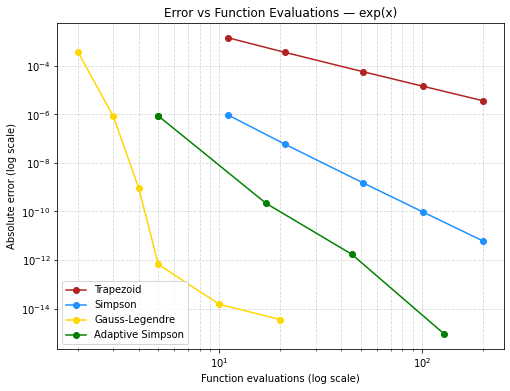

In [34]:
plot_results(df, "exp(x)")

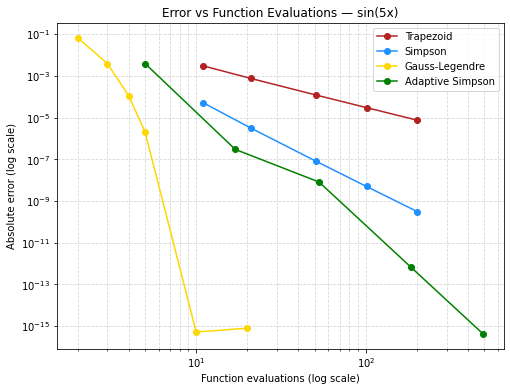

In [35]:
plot_results(df, "sin(5x)")

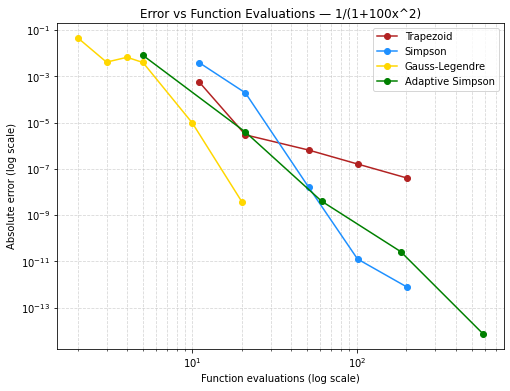

In [36]:
plot_results(df, "1/(1+100x^2)")

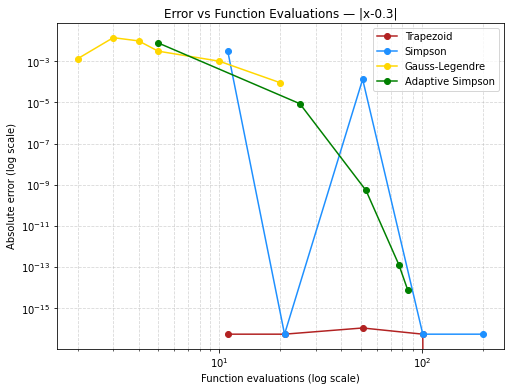

In [37]:
plot_results(df, "|x-0.3|")

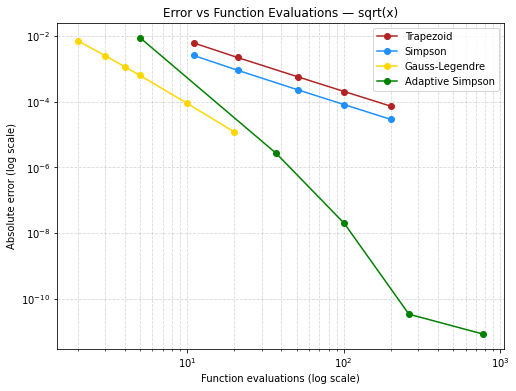

In [38]:
plot_results(df, "sqrt(x)")

<div style="background:#fafafa; padding:20px; border-radius:10px; 
            border:1px solid #ddd; font-size:110%;">

<b style="font-size:120%;">Black–Scholes Integrals</b>

<p>
To connect the quadrature methods with a realistic application, we consider 
integral representations arising in the Black–Scholes model for European 
options. These integrals combine smooth Gaussian behavior with payoff kinks 
at the strike, making them an excellent testbed for both high–order and 
adaptive numerical integration schemes.
</p>

<p><b>Call price as a lognormal integral</b></p>

<p>
Under the risk–neutral measure, the terminal stock price \(S_T\) is lognormally 
distributed. The European call price with strike \(K\), maturity \(T\), risk–free 
rate \(r\), and initial price \(S_0\) can be written as
</p>

$$
C = e^{-rT} \int_0^\infty (s - K)^+ f_{S_T}(s)\,ds,
$$

<p>
where \(f_{S_T}\) is the lognormal density of \(S_T\). The integrand is smooth 
for \(s \neq K\), but the payoff \((s-K)^+\) introduces a kink at \(s = K\). 
This non-smooth point is precisely the kind of feature that challenges fixed–step 
methods and highlights the advantages of adaptive quadrature.
</p>

<p><b>Vega and Gaussian integrals</b></p>

<p>
The Black–Scholes Vega measures the sensitivity of the call price to changes 
in volatility \(\sigma\). In closed form it is given by
</p>

$$
\text{Vega} = S_0 \sqrt{T}\,\phi(d_1),
$$

<p>
where \(\phi\) is the standard normal density and \(d_1\) is the usual 
Black–Scholes parameter. The Gaussian density itself admits the integral 
representation
</p>

$$
\phi(x) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{\infty} e^{-t^2/2}\,dt,
$$

<p>
which is smooth and rapidly decaying. Such integrals are particularly well 
suited to high–order methods like Gauss–Legendre quadrature, and they provide 
a clean contrast with the kinked call payoff integral.
</p>

<p>
In the following cells, we will approximate these Black–Scholes integrals using 
the trapezoidal rule, Simpson’s rule, Gauss–Legendre quadrature, and adaptive 
Simpson’s rule, and compare their accuracy and efficiency against the known 
closed–form Black–Scholes formulas.
</p>

</div>


In [39]:
def lognormal_pdf(s, S0, r, sigma, T):
    if s <= 0:
        return 0.0
    mu = np.log(S0) + (r - 0.5*sigma**2)*T
    var = sigma**2 * T
    return (1/(s*np.sqrt(2*np.pi*var))) * np.exp(-(np.log(s)-mu)**2/(2*var))

def call_integrand(s, K, S0, r, sigma, T):
    return max(s - K, 0) * lognormal_pdf(s, S0, r, sigma, T)

In [41]:
from mpmath import quad

def bs_call_price(S0, K, r, sigma, T):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

In [44]:
S0, K, r, sigma, T = 100, 100, 0.05, 0.2, 1.0
exact_call = bs_call_price(S0, K, r, sigma, T)

f_call = lambda s: call_integrand(s, K, S0, r, sigma, T)

results_call = compare_integrators(
    f_call, 
    0, 
    5*S0, 
    exact_call
)

df_call = pd.DataFrame(results_call, columns=["Method", "n_or_tol", "Approx", "Error", "Evals"])
df_call

,Method,n_or_tol,Approx,Error,Evals
0,Trapezoid,1.000000e+01,5.914933,4.535651,11
1,Trapezoid,2.000000e+01,9.869183,0.581400,21
2,Trapezoid,5.000000e+01,10.819952,0.369369,51
3,Trapezoid,1.000000e+02,10.945177,0.494594,101
4,Trapezoid,2.000000e+02,10.976116,0.525532,201
5,Simpson,1.000000e+01,7.750282,2.700301,11
6,Simpson,2.000000e+01,11.187267,0.736683,21
7,Simpson,5.000000e+01,10.995465,0.544881,51
8,Simpson,1.000000e+02,10.986919,0.536335,101
9,Simpson,2.000000e+02,10.986428,0.535845,201


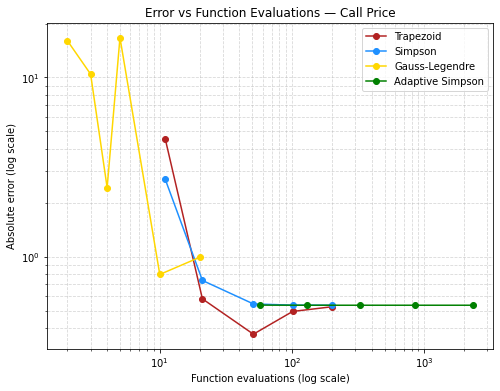

In [45]:
plot_results(df_call.assign(Function="Call Price"), "Call Price")

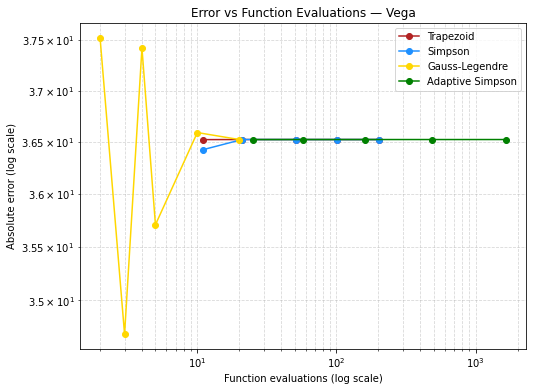

In [48]:
d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
f_vega = lambda x: np.exp(-0.5*x*x) / np.sqrt(2*np.pi)
exact_vega = S0 * np.sqrt(T) * f_vega(d1)

results_vega = compare_integrators(f_vega, -8, 8, exact_vega)
df_vega = pd.DataFrame(results_vega, columns=["Method", "n_or_tol", "Approx", "Error", "Evals"])
plot_results(df_vega.assign(Function="Vega"), "Vega")